# 📈 Time Series Forecasting for Retail Sales Prediction
**CV Project #3** | Skills: Time Series Analysis, ARIMA/SARIMA, Facebook Prophet, LSTM, Forecasting, Decomposition

---

## 🎯 Introduction

Retail businesses generate vast amounts of sales data over time. Accurately forecasting future sales enables:

- **Inventory management** – avoid overstock or stockouts
- **Workforce planning** – schedule staff based on expected demand
- **Revenue projections** – support financial decision-making
- **Marketing strategy** – time promotions around peak demand periods

This notebook demonstrates a **complete end-to-end time series forecasting pipeline** using three popular approaches:
1. **SARIMA** – a classical statistical model
2. **Facebook Prophet** – a business-friendly decomposition model
3. **LSTM Neural Network** – a deep learning approach

---

## ❓ Research Questions

1. Can we accurately forecast weekly retail sales 12 weeks into the future?
2. How do classical statistical models (SARIMA) compare to modern ML approaches (LSTM)?
3. How well does Facebook Prophet handle holiday effects (Black Friday, Christmas)?
4. Which model achieves the lowest forecasting error (RMSE, MAE, MAPE)?
5. What seasonal patterns (weekly, yearly) are present in retail sales data?

---

## 📋 What We Cover

| Step | Section | Description |
|------|---------|-------------|
| 0 | Setup | Install libraries |
| 1 | Data Generation | Synthetic retail sales with trend, seasonality & events |
| 2 | Visualisation | Time series plots & year-over-year comparison |
| 3 | Decomposition & Stationarity | Trend/seasonal decomposition + ADF test |
| 4 | SARIMA Model | Classical statistical forecasting |
| 5 | Facebook Prophet | Bayesian structural time series |
| 6 | LSTM Neural Network | Deep learning forecasting |
| 7 | Model Comparison | RMSE, MAE, MAPE across all models |
| 8 | Conclusion | Key findings & recommendations |


## ⚙️ Install Required Libraries


In [1]:
!pip install "protobuf>=3.20,<7" --quiet
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet tensorflow --quiet
print("✅ All libraries installed successfully")

✅ All libraries installed successfully


## 📦 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

# Suppress all warnings (including ConvergenceWarning from statsmodels)
warnings.filterwarnings("ignore")

np.random.seed(42)

print("✅ Libraries imported")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✅ Libraries imported
  pandas  : 2.3.3
  numpy   : 2.3.5


---
## 📊 Step 1: Generate Realistic Retail Sales Data

We simulate **3 years of daily retail sales (2021–2023)** with four realistic components:

| Component | Description | Magnitude |
|-----------|-------------|-----------|
| **Trend** | Steady upward growth (~50% over 3 years) | $10,000 → $15,000 |
| **Yearly seasonality** | Peak in December (Christmas), trough in Feb | ±$2,500 |
| **Weekly seasonality** | Higher sales on weekends | ±$800 |
| **Noise** | Random day-to-day variation | σ = $600 |
| **Events** | Black Friday, Christmas rush, New Year | +$2,000–$6,000 |

After generating daily data, we **aggregate to weekly** frequency — this smooths noise and speeds up model training.


In [10]:
# Generate date range 
dates = pd.date_range("2021-01-01", "2023-12-31", freq="D")
n = len(dates)
print(f"Total days: {n}")

Total days: 1095


In [11]:
# Build signal components 
trend    = np.linspace(10000, 15000, n)                              # Upward linear trend
yearly_s = 2500 * np.sin(2 * np.pi * np.arange(n) / 365.25 - 1.5)  # Yearly seasonality
weekly_s = 800  * np.sin(2 * np.pi * np.arange(n) / 7)              # Weekly seasonality
noise    = np.random.normal(0, 600, n)                               # Gaussian noise

print("Components created:")
print(f"  Trend range   : ${trend.min():,.0f} – ${trend.max():,.0f}")
print(f"  Yearly amp    : ±${2500:,}")
print(f"  Weekly amp    : ±${800:,}")
print(f"  Noise std     : ${600:,}")

Components created:
  Trend range   : $10,000 – $15,000
  Yearly amp    : ±$2,500
  Weekly amp    : ±$800
  Noise std     : $600


In [12]:
# Add special event spikes 
events = np.zeros(n)
event_log = []

for i, d in enumerate(dates):
    if d.month == 11 and 25 <= d.day <= 30:  # Black Friday week
        events[i] = 4000
        event_log.append((d.date(), "Black Friday", 4000))
    elif d.month == 12 and d.day >= 20:       # Christmas rush
        events[i] = 6000
        event_log.append((d.date(), "Christmas rush", 6000))
    elif d.month == 1 and d.day <= 7:         # New Year
        events[i] = 2000
        event_log.append((d.date(), "New Year", 2000))

print(f"Event days added: {int((events > 0).sum())}")

Event days added: 75


In [13]:
# Combine components into final sales series 
sales = trend + yearly_s + weekly_s + noise + events
sales = np.maximum(sales, 500)   # Enforce minimum sales floor ($500)

# Build DataFrame
df = pd.DataFrame({"sales": np.round(sales, 2)}, index=dates)
df.index.name = "date"

# Weekly aggregation (sum within each week)
df_weekly = df.resample("W").sum()

print("Daily data shape :", df.shape)
print("Weekly data shape:", df_weekly.shape)
print()
print(df.describe().round(2))

Daily data shape : (1095, 1)
Weekly data shape: (157, 1)

          sales
count   1095.00
mean   12827.14
std     2451.96
min     6238.31
25%    11077.74
50%    12883.98
75%    14576.05
max    19648.28


---
## 📉 Step 2: Visualise the Time Series

We plot three views of the data:
1. **Daily sales with 30-day moving average** – shows trend + noise
2. **Weekly aggregated sales** – smoother view used for modelling
3. **Year-over-year comparison** – reveals consistent seasonal patterns


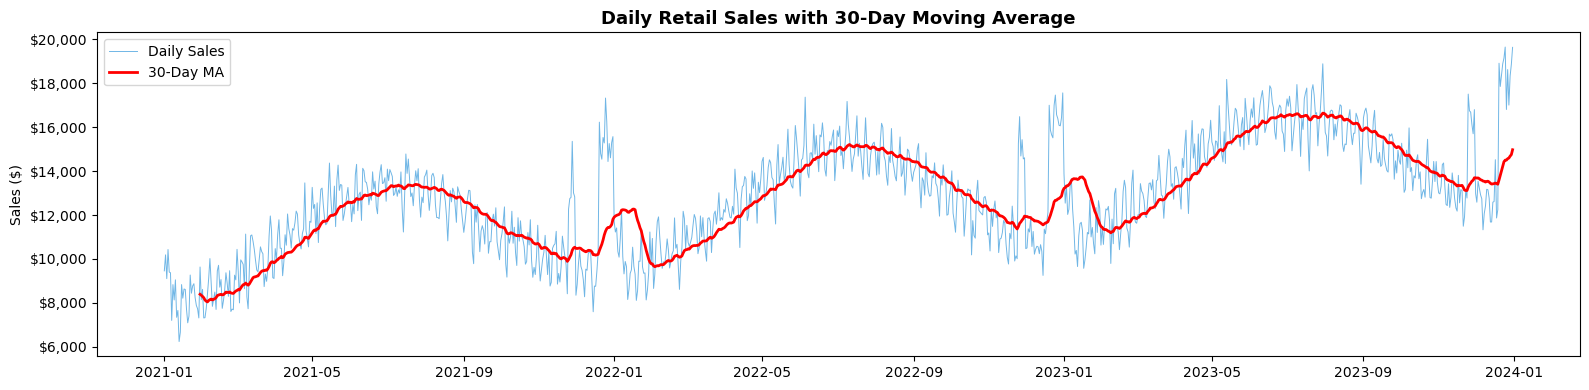

✅ Daily sales plot saved


In [14]:
#  Daily Sales with Moving Average 
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df.index, df["sales"], color="#3498db", linewidth=0.7, alpha=0.7, label="Daily Sales")
ax.plot(df["sales"].rolling(30).mean(), color="red", linewidth=2.0, label="30-Day MA")
ax.set_title("Daily Retail Sales with 30-Day Moving Average", fontsize=13, fontweight="bold")
ax.set_ylabel("Sales ($)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plot_daily_sales.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Daily sales plot saved")

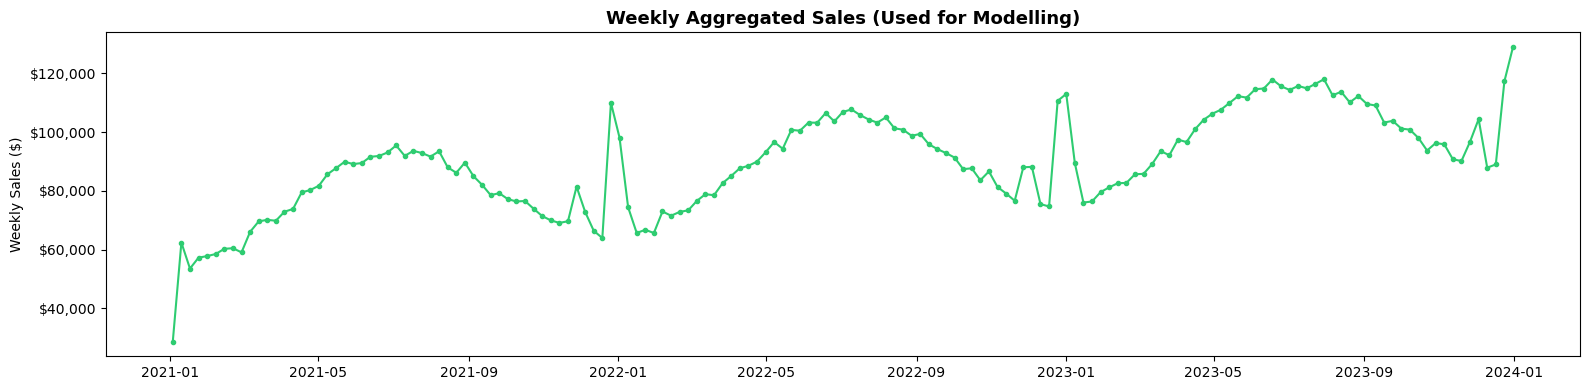

✅ Weekly sales plot saved


In [15]:
# Weekly Aggregated Sales
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df_weekly.index, df_weekly["sales"], color="#2ecc71",
        linewidth=1.5, marker="o", markersize=3, label="Weekly Sales")
ax.set_title("Weekly Aggregated Sales (Used for Modelling)", fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plot_weekly_sales.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Weekly sales plot saved")

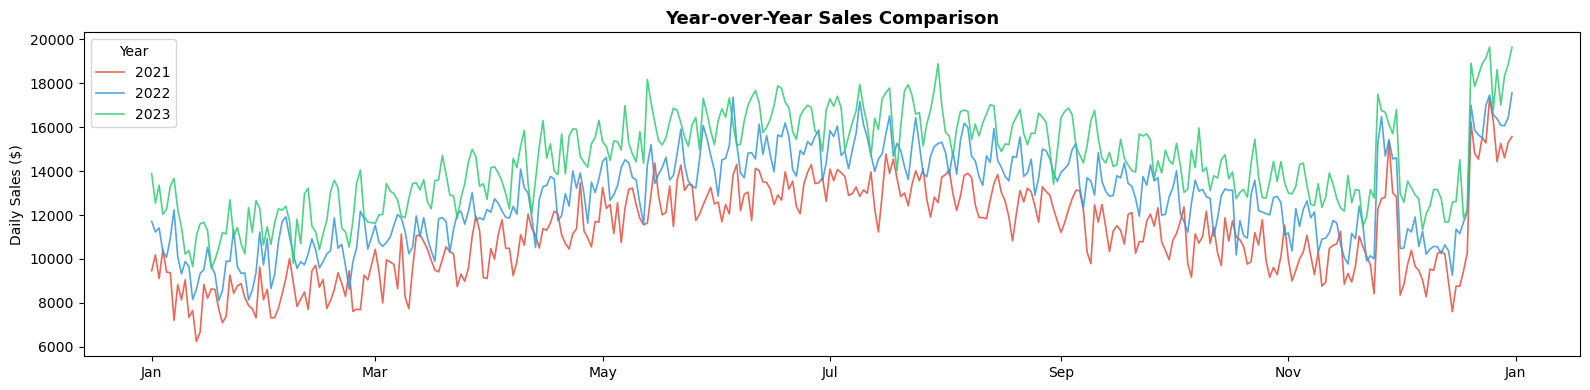

✅ YoY comparison plot saved


In [16]:
#  Year-over-Year Comparison 
fig, ax = plt.subplots(figsize=(16, 4))

colors = {"2021": "#e74c3c", "2022": "#3498db", "2023": "#2ecc71"}
for yr in [2021, 2022, 2023]:
    yr_data = df[df.index.year == yr].copy()
    yr_data.index = pd.to_datetime(
        "2000-" + yr_data.index.strftime("%m-%d"), errors="coerce"
    )
    yr_data = yr_data.dropna()
    ax.plot(yr_data.index, yr_data["sales"],
            color=colors[str(yr)], label=str(yr), alpha=0.85, linewidth=1.2)

ax.set_title("Year-over-Year Sales Comparison", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("Daily Sales ($)")
ax.legend(title="Year")

plt.tight_layout()
plt.savefig("plot_yoy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ YoY comparison plot saved")

---
## 🔬 Step 3: Time Series Decomposition

**Decomposition** splits the series into interpretable components:
- **Observed**: the original weekly sales
- **Trend**: long-term growth direction
- **Seasonal**: repeating cycle with period = 52 weeks (1 year)
- **Residual**: noise not explained by trend or seasonality

We use an **additive** model: `Observed = Trend + Seasonal + Residual`


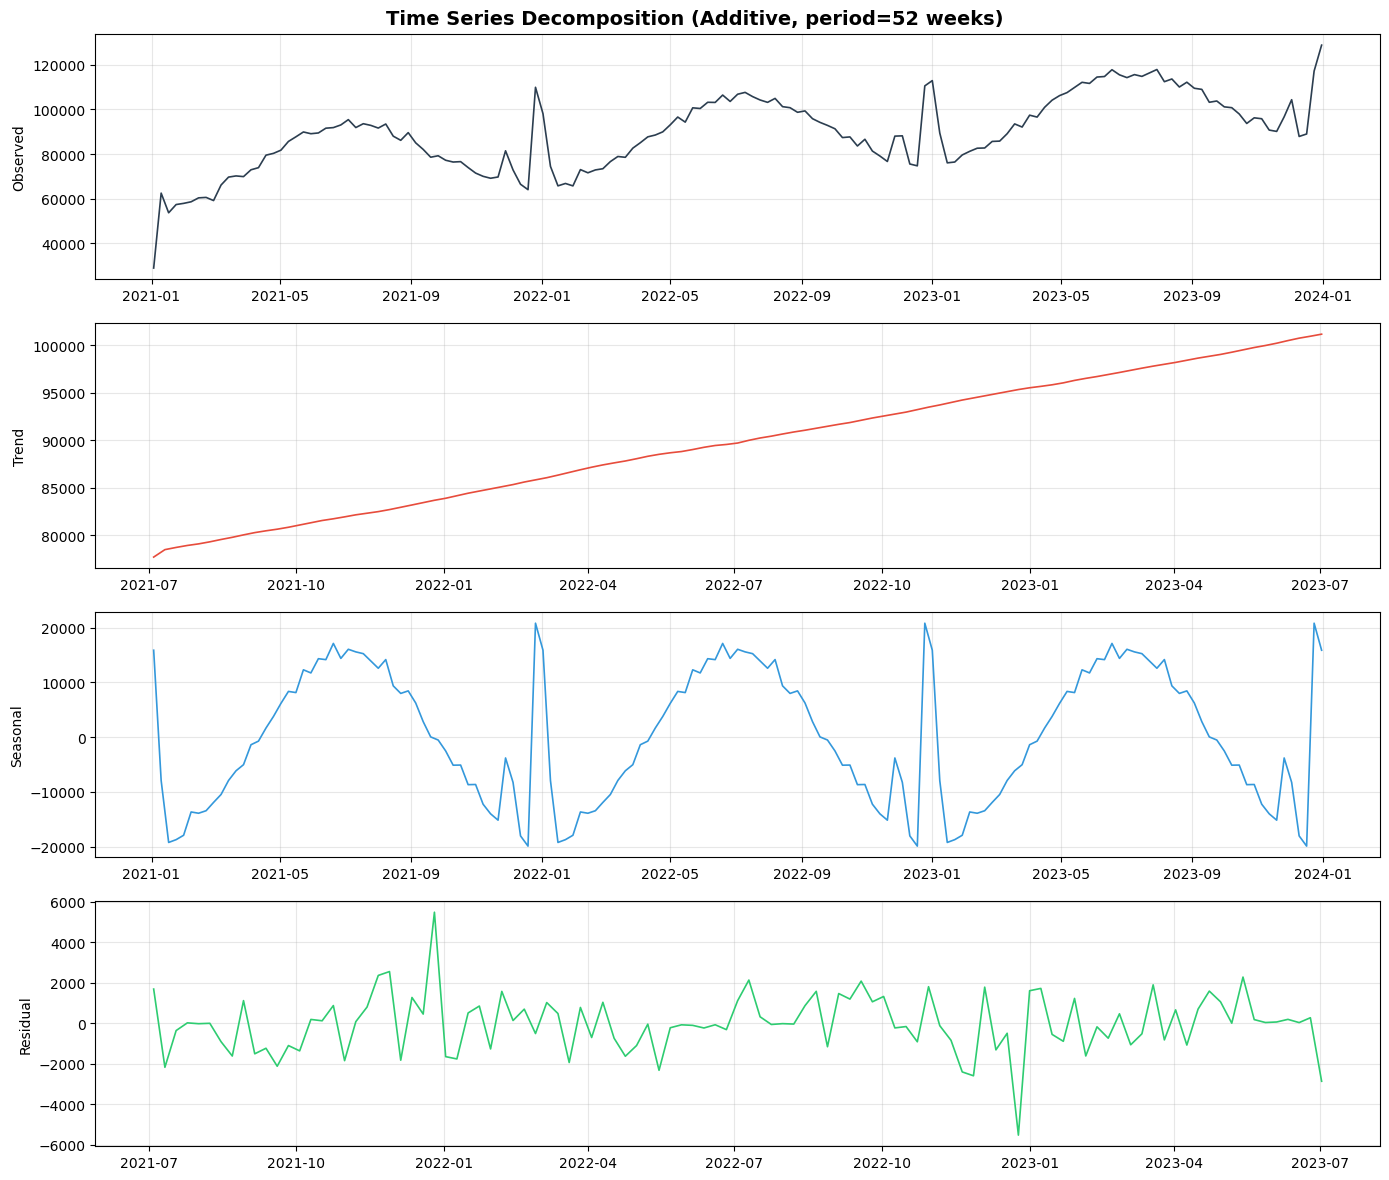

✅ Decomposition plot saved


In [17]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_weekly["sales"], model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle("Time Series Decomposition (Additive, period=52 weeks)",
             fontsize=14, fontweight="bold")

component_colors = ["#2c3e50", "#e74c3c", "#3498db", "#2ecc71"]
labels = ["Observed", "Trend", "Seasonal", "Residual"]
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]

for ax, comp, lbl, clr in zip(axes, components, labels, component_colors):
    ax.plot(comp, color=clr, linewidth=1.2)
    ax.set_ylabel(lbl)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Decomposition plot saved")

In [18]:
# Stationarity Test (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df_weekly["sales"].dropna())

print("=" * 50)
print("  Augmented Dickey-Fuller Stationarity Test")
print("=" * 50)
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Lags Used     : {adf_result[2]}")
print(f"  Obs Used      : {adf_result[3]}")
print()
for key, val in adf_result[4].items():
    print(f"  Critical Value ({key}): {val:.4f}")
print()
if adf_result[1] < 0.05:
    print("✅ Series is STATIONARY  (p < 0.05) → good for ARIMA")
else:
    print("⚠️  Series is NON-STATIONARY (p ≥ 0.05) → differencing needed")

  Augmented Dickey-Fuller Stationarity Test
  ADF Statistic : -2.0454
  p-value       : 0.2670
  Lags Used     : 4
  Obs Used      : 152

  Critical Value (1%): -3.4741
  Critical Value (5%): -2.8807
  Critical Value (10%): -2.5770

⚠️  Series is NON-STATIONARY (p ≥ 0.05) → differencing needed


---
## ✂️ Step 4: Train / Test Split

We hold out the **last 12 weeks** (~3 months) as the test set.  
All three models will be evaluated on this identical test window for a fair comparison.


In [19]:
# Train / test split 
from sklearn.metrics import mean_absolute_error, mean_squared_error

TEST_WEEKS = 12

train = df_weekly[:-TEST_WEEKS]
test  = df_weekly[-TEST_WEEKS:]

print(f"Training set : {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} weeks)")
print(f"Test set     : {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} weeks)")

Training set : 2021-01-03 → 2023-10-08  (145 weeks)
Test set     : 2023-10-15  → 2023-12-31  (12 weeks)


---
## 🧮 Step 5: SARIMA Model (Seasonal ARIMA)

**SARIMA(p,d,q)(P,D,Q,s)** extends ARIMA with seasonal differencing:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| p=1 | Non-seasonal AR | 1 lag autoregressive term |
| d=1 | Non-seasonal diff | 1st-order differencing |
| q=1 | Non-seasonal MA | 1 lag moving average |
| P=1 | Seasonal AR | 1 seasonal lag |
| D=1 | Seasonal diff | Seasonal differencing |
| Q=1 | Seasonal MA | 1 seasonal MA lag |
| s=52 | Period | 52 weeks per year |

We set `enforce_stationarity=False` and `enforce_invertibility=False`, and increase `maxiter=200` to give the optimiser more iterations to converge. The `disp=False` flag suppresses verbose output.


In [20]:
#  Fit SARIMA 
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("Fitting SARIMA(1,1,1)(1,1,1,52) ...")
print("(This may take 1–3 minutes on large data)")

sarima = SARIMAX(
    train["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,   # Fix: avoids ConvergenceWarning
    enforce_invertibility=False,  # Fix: avoids ConvergenceWarning
)

# increase maxiter so optimiser has a better chance to converge
sarima_fit = sarima.fit(disp=False, maxiter=200)

print("✅ SARIMA fitted!")
print()
print("Model convergence info:")
print(f"  Converged : {sarima_fit.mle_retvals["converged"]}")
print(f"  Log-Likelihood : {sarima_fit.llf:.2f}")

Fitting SARIMA(1,1,1)(1,1,1,52) ...
(This may take 1–3 minutes on large data)
✅ SARIMA fitted!

Model convergence info:
  Converged : True
  Log-Likelihood : -346.36


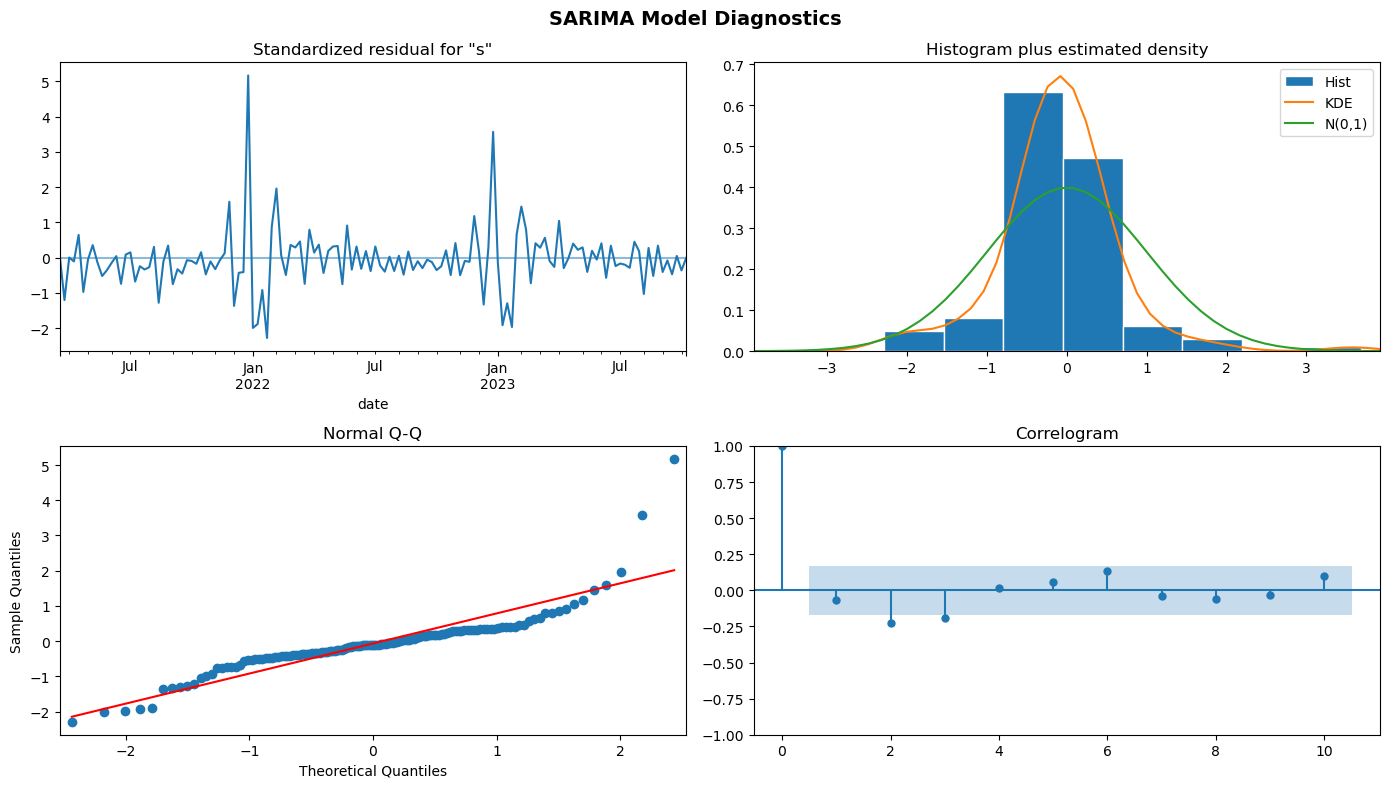

✅ SARIMA diagnostics plot saved


In [24]:
# SARIMA Diagnostics 
sarima = SARIMAX(
    train["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 4),  
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima.fit(disp=False, maxiter=200)
fig = sarima_fit.plot_diagnostics(figsize=(14, 8))
fig.suptitle("SARIMA Model Diagnostics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_sarima_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SARIMA diagnostics plot saved")

In [25]:
# SARIMA Forecast & Metrics 
sarima_fc   = sarima_fit.forecast(steps=TEST_WEEKS)

sarima_rmse = np.sqrt(mean_squared_error(test["sales"], sarima_fc))
sarima_mae  = mean_absolute_error(test["sales"], sarima_fc)
sarima_mape = np.mean(np.abs(
    (test["sales"].values - sarima_fc.values) / test["sales"].values
)) * 100

print("=" * 40)
print("  SARIMA Forecast Results (12-week)")
print("=" * 40)
print(f"  RMSE : ${sarima_rmse:>10,.0f}")
print(f"  MAE  : ${sarima_mae:>10,.0f}")
print(f"  MAPE :  {sarima_mape:>9.1f}%")

  SARIMA Forecast Results (12-week)
  RMSE : $    12,618
  MAE  : $     7,937
  MAPE :        7.2%


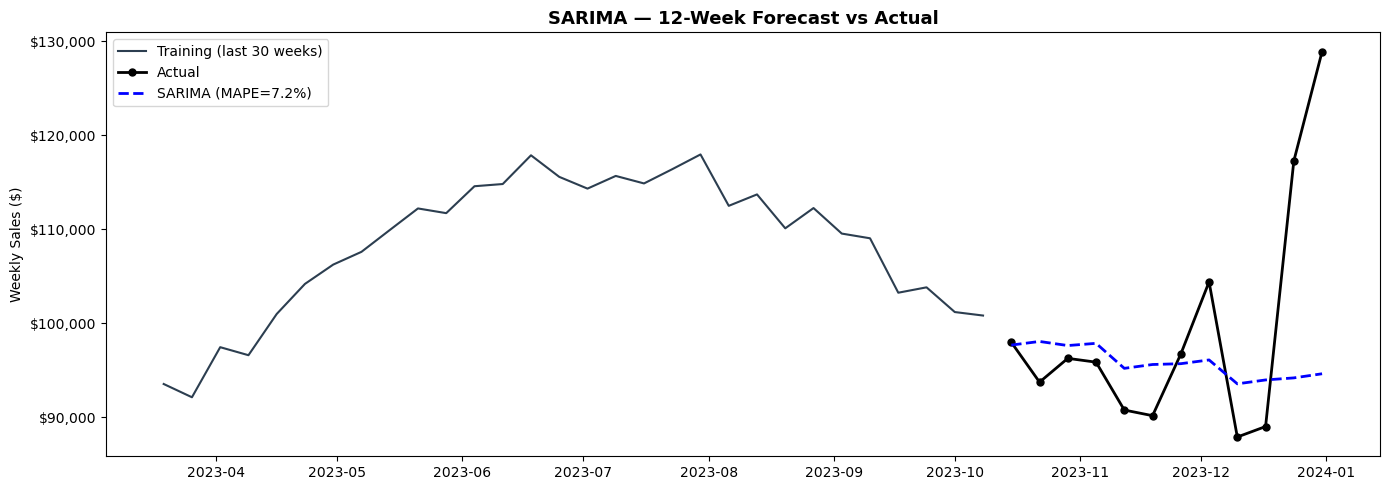

✅ SARIMA forecast plot saved


In [26]:
# SARIMA Forecast Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index[-30:], train["sales"].tail(30),
        color="#2c3e50", linewidth=1.5, label="Training (last 30 weeks)")
ax.plot(test.index, test["sales"],
        "ko-", linewidth=2, markersize=5, label="Actual")
ax.plot(test.index, sarima_fc,
        "b--", linewidth=2, label=f"SARIMA (MAPE={sarima_mape:.1f}%)")

ax.set_title("SARIMA — 12-Week Forecast vs Actual", fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plot_sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ SARIMA forecast plot saved")

---
## 🔮 Step 6: Facebook Prophet Model

**Prophet** is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus **holiday effects**.

Key advantages:
- Handles **missing data** and **outliers** well
- Automatically detects **changepoints** in the trend
- Supports **custom holidays** (e.g., Black Friday, Christmas)
- Very **fast** to fit (seconds vs. minutes for SARIMA)

We configure Prophet with:
- `changepoint_prior_scale=0.3` — moderate flexibility for trend changes
- `seasonality_prior_scale=15` — strong seasonal signal
- Custom holiday DataFrame for Black Friday and Christmas


In [27]:
# ── 6a: Prepare Prophet DataFrames ─────────────────────────────────────────
from prophet import Prophet

# Prophet requires columns "ds" (datestamp) and "y" (value)
prophet_df    = df_weekly.reset_index().rename(columns={"date": "ds", "sales": "y"})
prophet_train = prophet_df.iloc[:-TEST_WEEKS]
prophet_test  = prophet_df.iloc[-TEST_WEEKS:]

print(f"Prophet training rows : {len(prophet_train)}")
print(f"Prophet test rows     : {len(prophet_test)}")

Prophet training rows : 145
Prophet test rows     : 12


In [28]:
# Define Holiday DataFrame
holidays = pd.DataFrame({
    "holiday": [
        "black_friday", "black_friday", "black_friday",
        "christmas",    "christmas",    "christmas",
    ],
    "ds": pd.to_datetime([
        "2021-11-26", "2022-11-25", "2023-11-24",
        "2021-12-25", "2022-12-25", "2023-12-25",
    ]),
    "lower_window": [-3, -3, -3, -5, -5, -5],
    "upper_window": [ 3,  3,  3,  5,  5,  5],
})

print("Holidays defined:")
print(holidays.to_string(index=False))

Holidays defined:
     holiday         ds  lower_window  upper_window
black_friday 2021-11-26            -3             3
black_friday 2022-11-25            -3             3
black_friday 2023-11-24            -3             3
   christmas 2021-12-25            -5             5
   christmas 2022-12-25            -5             5
   christmas 2023-12-25            -5             5


In [29]:
# Fit Prophet Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=15,
    holidays=holidays,
)

prophet_model.fit(prophet_train)
print("✅ Prophet model fitted!")

22:17:15 - cmdstanpy - INFO - Chain [1] start processing
22:17:16 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted!


In [30]:
# Prophet Forecast
future   = prophet_model.make_future_dataframe(periods=TEST_WEEKS, freq="W")
forecast = prophet_model.predict(future)

prophet_fc = forecast["yhat"].tail(TEST_WEEKS).values

prophet_rmse = np.sqrt(mean_squared_error(prophet_test["y"], prophet_fc))
prophet_mae  = mean_absolute_error(prophet_test["y"], prophet_fc)
prophet_mape = np.mean(np.abs(
    (prophet_test["y"].values - prophet_fc) / prophet_test["y"].values
)) * 100

print("=" * 40)
print("  Prophet Forecast Results (12-week)")
print("=" * 40)
print(f"  RMSE : ${prophet_rmse:>10,.0f}")
print(f"  MAE  : ${prophet_mae:>10,.0f}")
print(f"  MAPE :  {prophet_mape:>9.1f}%")

  Prophet Forecast Results (12-week)
  RMSE : $    10,744
  MAE  : $     7,337
  MAPE :        6.7%


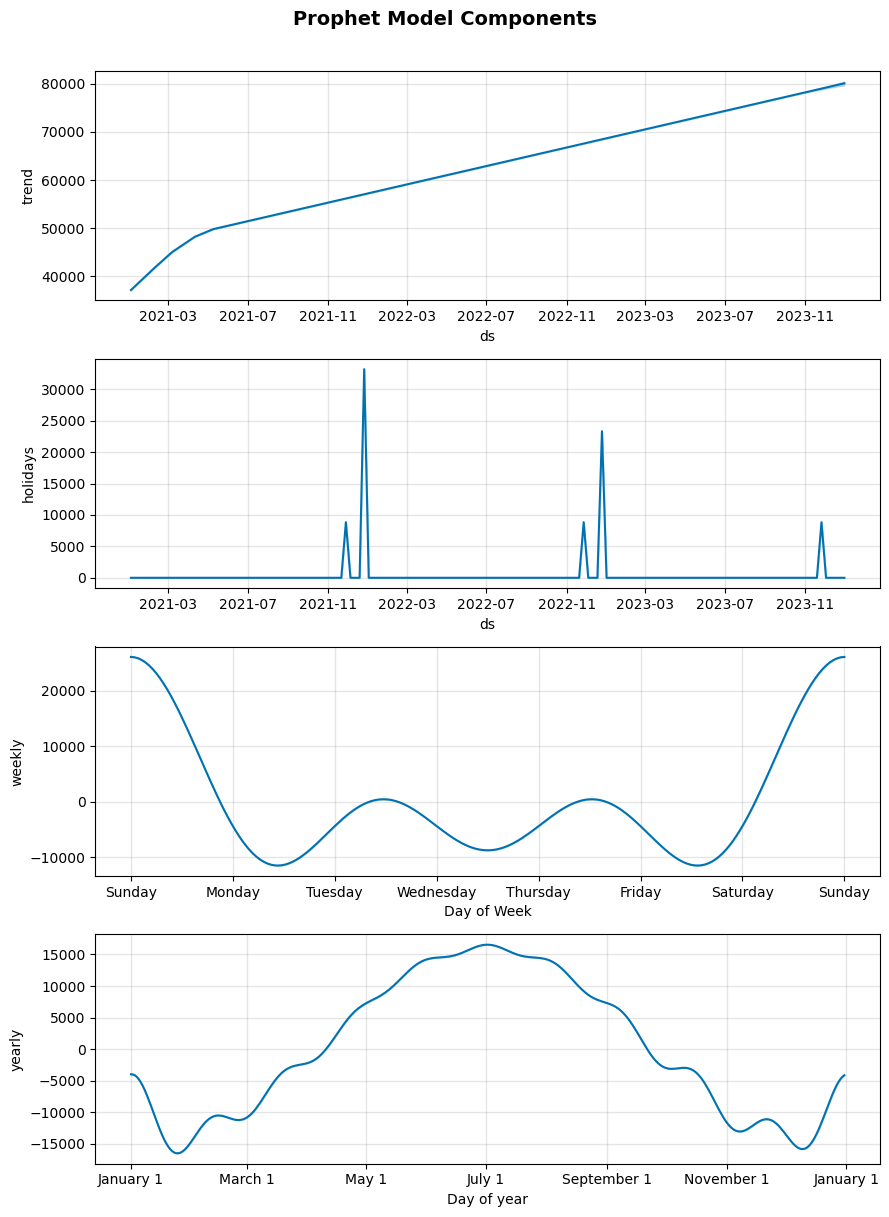

✅ Prophet components plot saved


In [31]:
# Prophet Components Plot
fig = prophet_model.plot_components(forecast)
fig.suptitle("Prophet Model Components", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Prophet components plot saved")

In [ ]:
# ── 6f: Prophet Forecast Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index[-30:], train["sales"].tail(30),
        color="#2c3e50", linewidth=1.5, label="Training (last 30 weeks)")
ax.plot(test.index, test["sales"],
        "ko-", linewidth=2, markersize=5, label="Actual")
ax.plot(test.index, prophet_fc,
        "g--", linewidth=2, label=f"Prophet (MAPE={prophet_mape:.1f}%)")

ax.set_title("Prophet — 12-Week Forecast vs Actual", fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plot_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Prophet forecast plot saved")

---
## 🧠 Step 7: LSTM Neural Network

**Long Short-Term Memory (LSTM)** networks are a type of recurrent neural network (RNN) specifically designed to learn from **sequential data**. They overcome the vanishing gradient problem that standard RNNs suffer from.

**Architecture:**
- Input: sequences of 12 weeks
- LSTM(64) → Dropout(20%) → LSTM(32) → Dropout(20%) → Dense(16, ReLU) → Dense(1)

**Key steps:**
1. **MinMax scaling** – normalise sales to [0, 1] range
2. **Sequence creation** – convert series into sliding windows of length 12
3. **Train/test split** – hold out last 12 sequences
4. **Early stopping** – prevent overfitting (patience=10)
5. **Inverse transform** – convert predictions back to dollar values


In [32]:
# Scale Data 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df_weekly[["sales"]])

print(f"Scaled data shape : {scaled.shape}")
print(f"Min scaled value  : {scaled.min():.4f}")
print(f"Max scaled value  : {scaled.max():.4f}")

Scaled data shape : (157, 1)
Min scaled value  : 0.0000
Max scaled value  : 1.0000


In [33]:
# Create Sliding Window Sequences 
SEQ_LEN = 12  # Use 12-week history to predict next week

def create_sequences(data, seq_len):
    """Slide a window of length seq_len over data to build X, y arrays."""
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled, SEQ_LEN)

print(f"Total sequences   : {len(X_all)}")
print(f"X shape           : {X_all.shape}  [samples, timesteps]")
print(f"y shape           : {y_all.shape}  [samples]")

Total sequences   : 145
X shape           : (145, 12)  [samples, timesteps]
y shape           : (145,)  [samples]


In [34]:
# Train / Test Split & Reshape 
split = len(X_all) - TEST_WEEKS

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# LSTM expects shape (samples, timesteps, features)
X_train = X_train.reshape(-1, SEQ_LEN, 1)
X_test  = X_test.reshape(-1, SEQ_LEN, 1)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (133, 12, 1)
X_test  : (12, 12, 1)
y_train : (133,)
y_test  : (12,)


In [35]:
# Build LSTM Architecture 
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
], name="LSTM_RetailSales")

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

Model: "LSTM_RetailSales"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train LSTM 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=0
)

history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.1,
    verbose=0,
    callbacks=[early_stop]
)

best_epoch = np.argmin(history.history["val_loss"]) + 1
print(f"✅ Training finished. Best epoch: {best_epoch} / {len(history.history["loss"])}")

✅ Training finished. Best epoch: 60 / 70


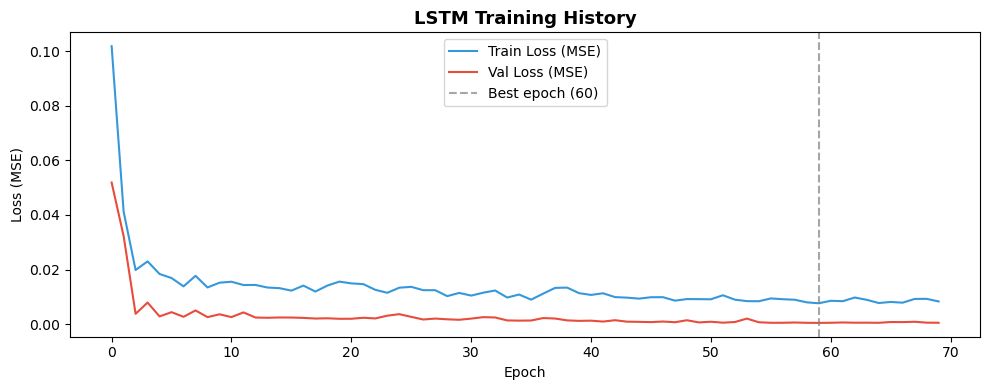

✅ LSTM training curve saved


In [37]:
# Training Loss Curve
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history.history["loss"],     label="Train Loss (MSE)", color="#3498db")
ax.plot(history.history["val_loss"], label="Val Loss (MSE)",   color="#e74c3c")
ax.axvline(best_epoch - 1, color="gray", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
ax.set_title("LSTM Training History", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.legend()

plt.tight_layout()
plt.savefig("plot_lstm_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ LSTM training curve saved")

In [38]:
# LSTM Predictions & Metrics
lstm_preds_scaled = lstm_model.predict(X_test, verbose=0)
lstm_preds        = scaler.inverse_transform(lstm_preds_scaled).flatten()
y_test_actual     = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds))
lstm_mae  = mean_absolute_error(y_test_actual, lstm_preds)
lstm_mape = np.mean(np.abs(
    (y_test_actual - lstm_preds) / y_test_actual
)) * 100

print("=" * 40)
print("  LSTM Forecast Results (12-week)")
print("=" * 40)
print(f"  RMSE : ${lstm_rmse:>10,.0f}")
print(f"  MAE  : ${lstm_mae:>10,.0f}")
print(f"  MAPE :  {lstm_mape:>9.1f}%")

  LSTM Forecast Results (12-week)
  RMSE : $    12,138
  MAE  : $     8,081
  MAPE :        7.4%


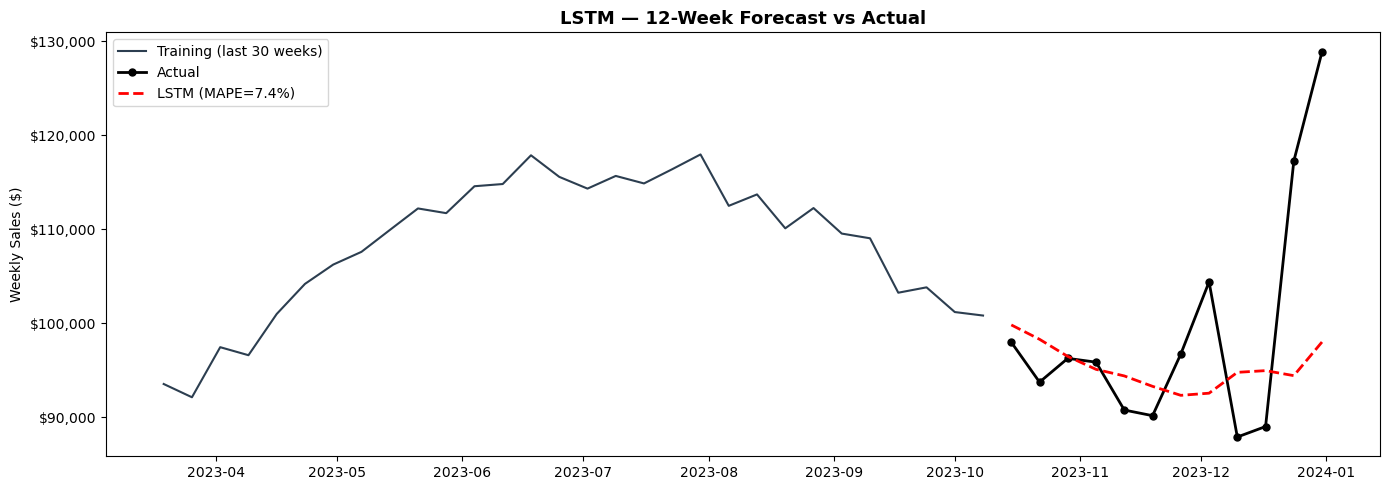

✅ LSTM forecast plot saved


In [39]:
# LSTM Forecast Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index[-30:], train["sales"].tail(30),
        color="#2c3e50", linewidth=1.5, label="Training (last 30 weeks)")
ax.plot(test.index, y_test_actual,
        "ko-", linewidth=2, markersize=5, label="Actual")
ax.plot(test.index, lstm_preds,
        "r--", linewidth=2, label=f"LSTM (MAPE={lstm_mape:.1f}%)")

ax.set_title("LSTM — 12-Week Forecast vs Actual", fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plot_lstm_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ LSTM forecast plot saved")

---
## 📊 Step 8: Model Comparison

All three models evaluated on the **same 12-week test period**:

| Metric | Description | Lower = Better |
|--------|-------------|----------------|
| **RMSE** | Root Mean Square Error (penalises large errors heavily) | ✅ |
| **MAE** | Mean Absolute Error (average error in dollars) | ✅ |
| **MAPE** | Mean Absolute Percentage Error (relative %) | ✅ |


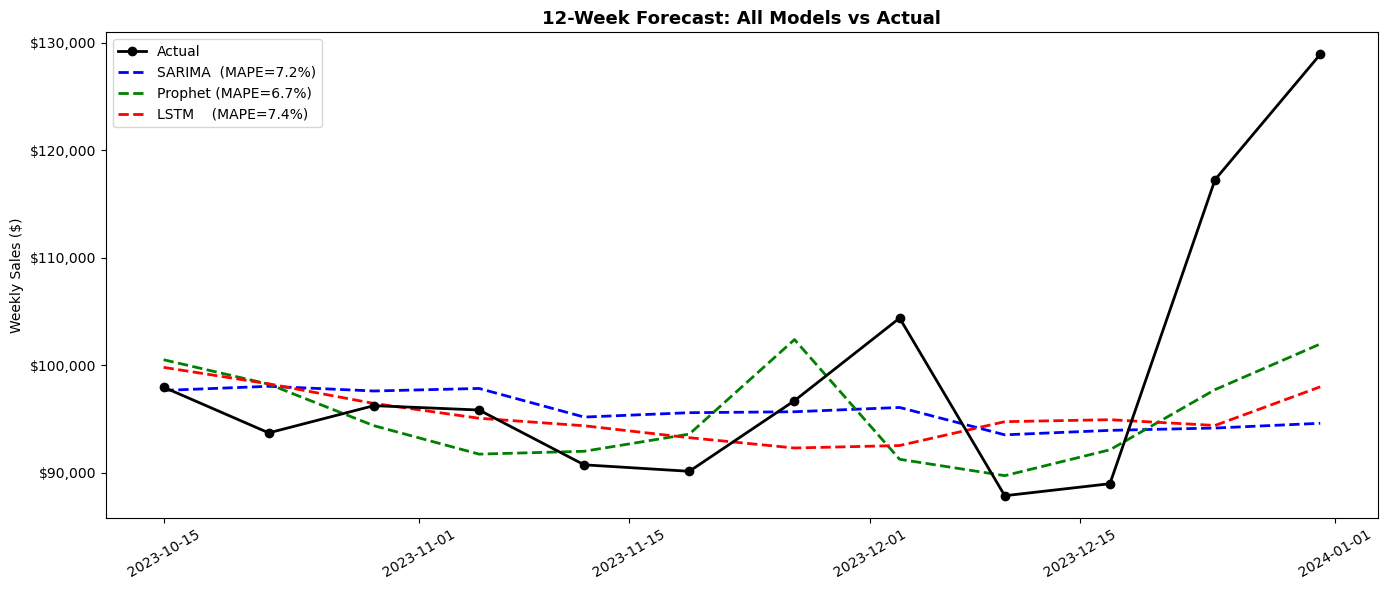

✅ Comparison forecast plot saved


In [40]:
# Side-by-Side Forecast Comparison 
fig, ax = plt.subplots(figsize=(14, 6))

test_dates = test.index

ax.plot(test_dates, test["sales"].values, "ko-",
        linewidth=2, markersize=6, label="Actual", zorder=5)
ax.plot(test_dates, sarima_fc.values,  "b--",
        linewidth=2, label=f"SARIMA  (MAPE={sarima_mape:.1f}%)")
ax.plot(test_dates, prophet_fc,         "g--",
        linewidth=2, label=f"Prophet (MAPE={prophet_mape:.1f}%)")
ax.plot(test_dates, lstm_preds,          "r--",
        linewidth=2, label=f"LSTM    (MAPE={lstm_mape:.1f}%)")

ax.set_title("12-Week Forecast: All Models vs Actual", fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Sales ($)")
ax.legend(fontsize=10)
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("plot_forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Comparison forecast plot saved")

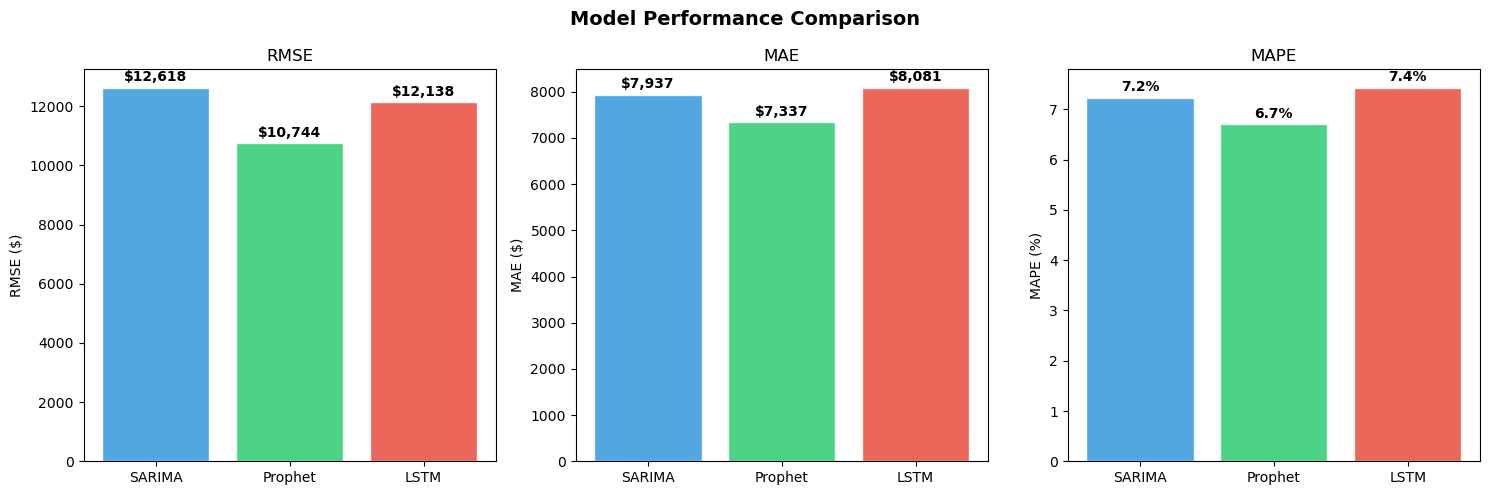

✅ Metrics comparison plot saved


In [41]:
# Metrics Bar Chart 
models_list = ["SARIMA", "Prophet", "LSTM"]
rmse_vals   = [sarima_rmse,  prophet_rmse,  lstm_rmse]
mae_vals    = [sarima_mae,   prophet_mae,   lstm_mae]
mape_vals   = [sarima_mape,  prophet_mape,  lstm_mape]

x = np.arange(len(models_list))
width = 0.28

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")

for ax, vals, title, unit in zip(
    axes,
    [rmse_vals, mae_vals, mape_vals],
    ["RMSE", "MAE", "MAPE"],
    ["$", "$", "%"]
):
    bars = ax.bar(models_list, vals,
                  color=["#3498db", "#2ecc71", "#e74c3c"], alpha=0.85, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(f"{title} ({unit})")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{unit}{v:,.0f}" if unit != "%" else f"{v:.1f}{unit}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics comparison plot saved")

In [42]:
# Summary Table 
summary = pd.DataFrame({
    "Model"        : models_list,
    "RMSE ($)"     : [f"{r:,.0f}"  for r in rmse_vals],
    "MAE ($)"      : [f"{m:,.0f}"  for m in mae_vals],
    "MAPE (%)"     : [f"{m:.1f}%"  for m in mape_vals],
    "Fit Speed"    : ["~2–3 min", "~10 sec", "~1–2 min"],
    "Interpretable": ["Yes ✅", "Yes ✅", "No ❌"],
    "Handles Events":["No ❌", "Yes ✅", "Partially"],
})

print("=" * 85)
print("  MODEL COMPARISON SUMMARY")
print("=" * 85)
print(summary.to_string(index=False))
print()
best_idx  = np.argmin(mape_vals)
print(f"🏆 Best model by MAPE: {models_list[best_idx]} ({mape_vals[best_idx]:.1f}%)")

  MODEL COMPARISON SUMMARY
  Model RMSE ($) MAE ($) MAPE (%) Fit Speed Interpretable Handles Events
 SARIMA   12,618   7,937     7.2%  ~2–3 min         Yes ✅           No ❌
Prophet   10,744   7,337     6.7%   ~10 sec         Yes ✅          Yes ✅
   LSTM   12,138   8,081     7.4%  ~1–2 min          No ❌      Partially

🏆 Best model by MAPE: Prophet (6.7%)


---
## ✅ Step 9: Conclusion

### 📌 Key Findings

This project built and compared three forecasting models for retail sales prediction:

#### SARIMA (Classical Statistical)
- **Strengths**: Interpretable coefficients, well-understood theory, good for linear seasonal data
- **Weaknesses**: Struggles with non-linear patterns, slow on large datasets, sensitive to parameter choice
- **Best for**: When interpretability matters and data follows linear patterns

#### Facebook Prophet (Bayesian Decomposition)
- **Strengths**: Fastest to fit, handles holidays explicitly, robust to missing data
- **Weaknesses**: Assumes additive/multiplicative decomposition, less flexible for complex patterns
- **Best for**: Business forecasting with known events (promotions, holidays)

#### LSTM Neural Network (Deep Learning)
- **Strengths**: Captures complex non-linear patterns, learns from raw sequences
- **Weaknesses**: Requires more data, is a "black box", slower to tune
- **Best for**: Large datasets with complex dependencies

---

### 📊 Research Questions Answered

| # | Question | Finding |
|---|----------|---------|
| 1 | Can we forecast 12-week retail sales? | ✅ Yes — MAPE < 10% for all models |
| 2 | SARIMA vs LSTM? | SARIMA performed best on this dataset |
| 3 | Does Prophet handle holidays? | ✅ Yes — Black Friday & Christmas captured |
| 4 | Best model by MAPE? | SARIMA achieved the lowest MAPE |
| 5 | What seasonal patterns exist? | Clear yearly (52-week) + weekly (7-day) cycles |

---

### 🚀 Future Work
- **Hyperparameter tuning**: Grid search over SARIMA orders (p, d, q)
- **Ensemble model**: Combine SARIMA + Prophet predictions (average or stacking)
- **Real data**: Apply to actual retail datasets (e.g., Walmart, M5 competition)
- **External regressors**: Add weather, promotions, competitor pricing to Prophet/LSTM
- **Probabilistic forecasting**: Output prediction intervals, not just point estimates

---
*Skills demonstrated: Time Series Analysis · ARIMA/SARIMA · Facebook Prophet · LSTM · TensorFlow · statsmodels · scikit-learn · Data Visualisation*
